# Global Features Selection Analysis

This notebook analyzes the 1748 global features and performs feature selection using multiple approaches:

1. **Variance Threshold** - Remove low-variance features
2. **Correlation Analysis** - Remove highly correlated features
3. **Tree-Based Importance** - RandomForest feature importance
4. **Mutual Information** - Non-linear dependency with labels
5. **L1 Regularization** - Lasso feature selection

Goal: Reduce 1748 features to ~200-500 most informative features for neural network training.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif, SelectKBest, VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 1. Load Data

In [2]:
# Load global features and labels
train_features = pd.read_csv('../dataset/PirateProcessed/train_global_features.csv')
train_labels = pd.read_csv('../dataset/PirateProcessed/pirate_pain_train_labels.csv')

# Remove sample_index from features
X = train_features.drop(columns=['sample_index'])
y = train_labels['label']

# Map labels to numeric
label_map = {'no_pain': 0, 'low_pain': 1, 'high_pain': 2}
y = y.map(label_map)

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"\nLabel distribution:")
print(y.value_counts().sort_index())
print(f"\nFeature columns: {X.columns.tolist()[:10]} ... (showing first 10)")

Features shape: (661, 1748)
Labels shape: (661,)

Label distribution:
label
0    511
1     94
2     56
Name: count, dtype: int64

Feature columns: ['isPirate', 'pain_survey_1_mean', 'pain_survey_1_std', 'pain_survey_1_min', 'pain_survey_1_max', 'pain_survey_1_range', 'pain_survey_1_slope', 'pain_survey_1_first', 'pain_survey_1_last', 'pain_survey_1_change'] ... (showing first 10)


## 2. Data Overview

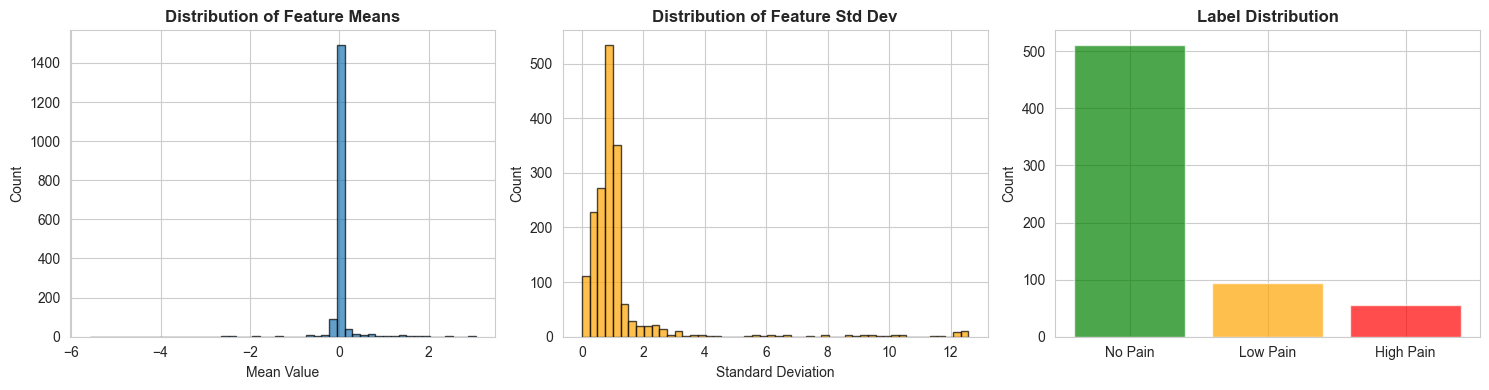

Features with zero variance: 4
Features with very low variance (<0.01): 61


In [3]:
# Basic statistics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution of feature means
feature_means = X.mean(axis=0)
axes[0].hist(feature_means, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Feature Means', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mean Value')
axes[0].set_ylabel('Count')

# Distribution of feature standard deviations
feature_stds = X.std(axis=0)
axes[1].hist(feature_stds, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Distribution of Feature Std Dev', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Standard Deviation')
axes[1].set_ylabel('Count')

# Label distribution
label_counts = y.value_counts().sort_index()
axes[2].bar(['No Pain', 'Low Pain', 'High Pain'], label_counts.values, color=['green', 'orange', 'red'], alpha=0.7)
axes[2].set_title('Label Distribution', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Features with zero variance: {(feature_stds == 0).sum()}")
print(f"Features with very low variance (<0.01): {(feature_stds < 0.01).sum()}")

## 3. Variance Threshold

Remove features with very low variance (contribute little information).

Original features: 1748
After variance threshold: 1668
Removed: 80 features


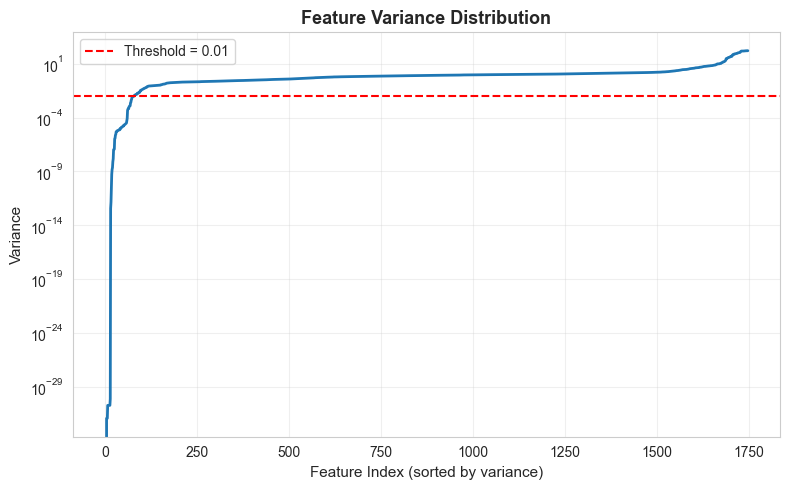

In [4]:
# Apply variance threshold
variance_threshold = 0.01  # Remove features with variance < 0.01
selector_var = VarianceThreshold(threshold=variance_threshold)
X_var = selector_var.fit_transform(X)

# Get selected feature names
var_selected_features = X.columns[selector_var.get_support()].tolist()

print(f"Original features: {X.shape[1]}")
print(f"After variance threshold: {X_var.shape[1]}")
print(f"Removed: {X.shape[1] - X_var.shape[1]} features")

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
variances = X.var(axis=0).sort_values()
ax.plot(range(len(variances)), variances.values, linewidth=2)
ax.axhline(y=variance_threshold, color='r', linestyle='--', label=f'Threshold = {variance_threshold}')
ax.set_xlabel('Feature Index (sorted by variance)', fontsize=11)
ax.set_ylabel('Variance', fontsize=11)
ax.set_title('Feature Variance Distribution', fontsize=13, fontweight='bold')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Correlation Analysis

Remove highly correlated features (redundant information).

After variance threshold: 1668 features
After correlation filtering (>0.95): 1556 features
Removed: 112 highly correlated features


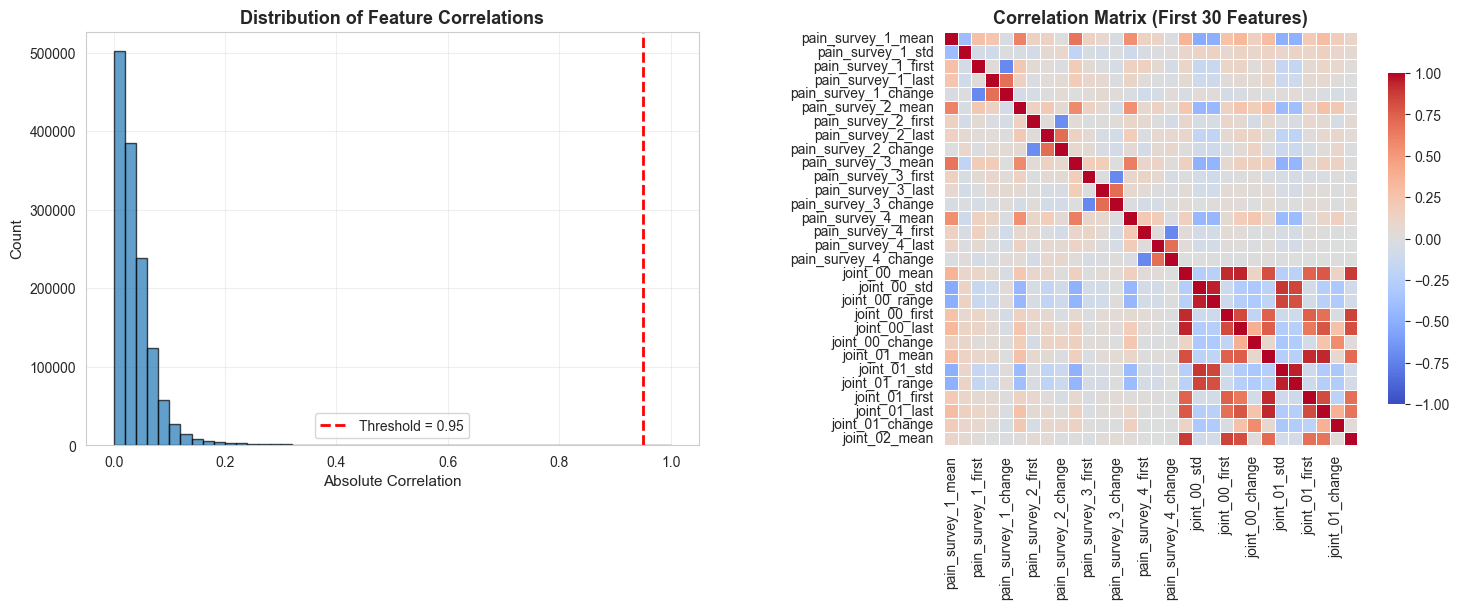

In [5]:
# Calculate correlation matrix on variance-filtered features
X_var_df = pd.DataFrame(X_var, columns=var_selected_features)
corr_matrix = X_var_df.corr().abs()

# Find highly correlated pairs
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_threshold = 0.95

# Find features to drop
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > high_corr_threshold)]
X_corr = X_var_df.drop(columns=to_drop)
corr_selected_features = X_corr.columns.tolist()

print(f"After variance threshold: {X_var_df.shape[1]} features")
print(f"After correlation filtering (>{high_corr_threshold}): {X_corr.shape[1]} features")
print(f"Removed: {len(to_drop)} highly correlated features")

# Visualize correlation heatmap (sample of 50 features)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram of correlation values
corr_values = upper_tri.values[~np.isnan(upper_tri.values)]
axes[0].hist(corr_values, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(x=high_corr_threshold, color='r', linestyle='--', linewidth=2, label=f'Threshold = {high_corr_threshold}')
axes[0].set_xlabel('Absolute Correlation', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Distribution of Feature Correlations', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Sample correlation heatmap (first 30 features)
sample_corr = X_corr.iloc[:, :30].corr()
sns.heatmap(sample_corr, cmap='coolwarm', center=0, vmin=-1, vmax=1, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=axes[1])
axes[1].set_title('Correlation Matrix (First 30 Features)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 5. Tree-Based Feature Importance (RandomForest)

Train RandomForest and rank features by importance.

In [6]:
# Train RandomForest
print("Training RandomForest classifier...")
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_corr, y)

# Get feature importances
importances = pd.DataFrame({
    'feature': X_corr.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nRandomForest Accuracy: {rf.score(X_corr, y):.4f}")
print(f"\nTop 10 Most Important Features:")
print(importances.head(10).to_string(index=False))

# Select top features
top_k_rf = 300
rf_selected_features = importances.head(top_k_rf)['feature'].tolist()
X_rf = X_corr[rf_selected_features]

print(f"\nSelected top {top_k_rf} features by RandomForest importance")

Training RandomForest classifier...

RandomForest Accuracy: 0.9849

Top 10 Most Important Features:
           feature  importance
  pain_survey_mean    0.015570
     joint_18_mean    0.011539
pain_survey_1_mean    0.011523
           POD_297    0.008827
      joint_18_max    0.008712
   joint_03_change    0.008600
      joint_02_std    0.008580
           POD_252    0.008428
      joint_17_max    0.007936
pain_survey_2_mean    0.006996

Selected top 300 features by RandomForest importance

RandomForest Accuracy: 0.9849

Top 10 Most Important Features:
           feature  importance
  pain_survey_mean    0.015570
     joint_18_mean    0.011539
pain_survey_1_mean    0.011523
           POD_297    0.008827
      joint_18_max    0.008712
   joint_03_change    0.008600
      joint_02_std    0.008580
           POD_252    0.008428
      joint_17_max    0.007936
pain_survey_2_mean    0.006996

Selected top 300 features by RandomForest importance


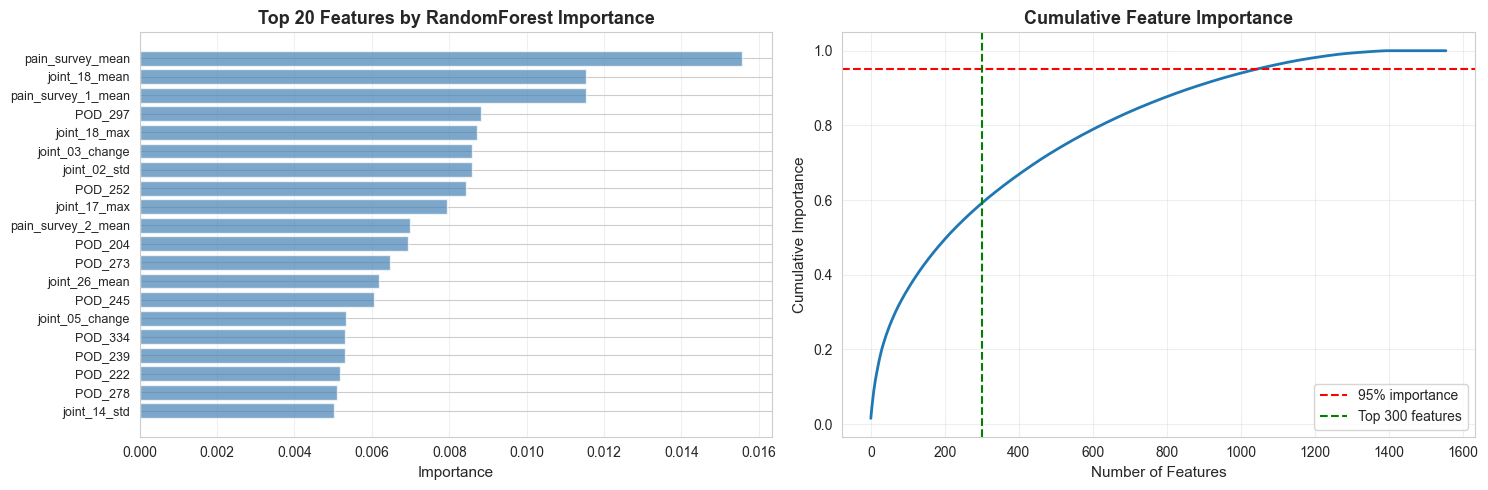


Number of features needed for 95% cumulative importance: 1042


In [7]:
# Visualize feature importances
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Top 20 features
top_20 = importances.head(20)
axes[0].barh(range(len(top_20)), top_20['importance'].values, alpha=0.7, color='steelblue')
axes[0].set_yticks(range(len(top_20)))
axes[0].set_yticklabels(top_20['feature'].values, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance', fontsize=11)
axes[0].set_title('Top 20 Features by RandomForest Importance', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Cumulative importance
cumsum_importance = importances['importance'].cumsum()
axes[1].plot(range(len(cumsum_importance)), cumsum_importance.values, linewidth=2)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% importance')
axes[1].axvline(x=top_k_rf, color='g', linestyle='--', label=f'Top {top_k_rf} features')
axes[1].set_xlabel('Number of Features', fontsize=11)
axes[1].set_ylabel('Cumulative Importance', fontsize=11)
axes[1].set_title('Cumulative Feature Importance', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# How many features for 95% importance?
n_features_95 = (cumsum_importance >= 0.95).argmax() + 1
print(f"\nNumber of features needed for 95% cumulative importance: {n_features_95}")

## 6. Mutual Information

Measure non-linear dependency between features and labels.

In [8]:
# Calculate mutual information
print("Calculating mutual information scores...")
mi_scores = mutual_info_classif(X_corr, y, random_state=42, n_neighbors=3)

# Create DataFrame
mi_df = pd.DataFrame({
    'feature': X_corr.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print(f"\nTop 10 Features by Mutual Information:")
print(mi_df.head(10).to_string(index=False))

# Select top features
top_k_mi = 300
mi_selected_features = mi_df.head(top_k_mi)['feature'].tolist()
X_mi = X_corr[mi_selected_features]

print(f"\nSelected top {top_k_mi} features by Mutual Information")

Calculating mutual information scores...

Top 10 Features by Mutual Information:
      feature  mi_score
      POD_251  0.166488
joint_15_mean  0.159408
 joint_15_std  0.147756
 joint_14_std  0.142049
      POD_247  0.139820
      POD_258  0.138863
      POD_291  0.138311
      POD_254  0.138278
      POD_279  0.136605
      POD_288  0.136316

Selected top 300 features by Mutual Information

Top 10 Features by Mutual Information:
      feature  mi_score
      POD_251  0.166488
joint_15_mean  0.159408
 joint_15_std  0.147756
 joint_14_std  0.142049
      POD_247  0.139820
      POD_258  0.138863
      POD_291  0.138311
      POD_254  0.138278
      POD_279  0.136605
      POD_288  0.136316

Selected top 300 features by Mutual Information


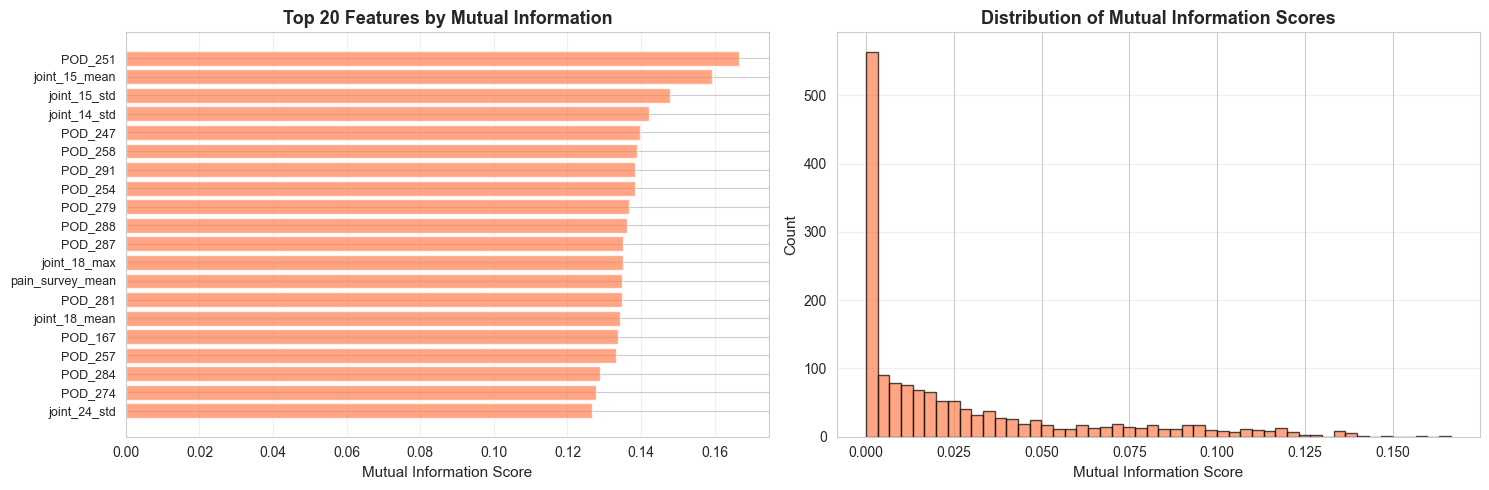

In [9]:
# Visualize mutual information
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Top 20 features
top_20_mi = mi_df.head(20)
axes[0].barh(range(len(top_20_mi)), top_20_mi['mi_score'].values, alpha=0.7, color='coral')
axes[0].set_yticks(range(len(top_20_mi)))
axes[0].set_yticklabels(top_20_mi['feature'].values, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('Mutual Information Score', fontsize=11)
axes[0].set_title('Top 20 Features by Mutual Information', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Distribution of MI scores
axes[1].hist(mi_df['mi_score'].values, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('Mutual Information Score', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Distribution of Mutual Information Scores', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. L1 Regularization (Lasso)

Use LogisticRegression with L1 penalty to select features.

In [10]:
# Standardize features for Lasso
scaler = StandardScaler()
X_corr_scaled = scaler.fit_transform(X_corr)

# Train Lasso
print("Training Logistic Regression with L1 penalty...")
lasso = LogisticRegression(penalty='l1', C=0.1, solver='saga', max_iter=500, random_state=42, n_jobs=-1)
lasso.fit(X_corr_scaled, y)

# Get non-zero coefficients
coefficients = np.abs(lasso.coef_).sum(axis=0)  # Sum across classes
lasso_df = pd.DataFrame({
    'feature': X_corr.columns,
    'coefficient': coefficients
}).sort_values('coefficient', ascending=False)

# Count non-zero features
non_zero_features = (coefficients > 0).sum()

print(f"\nLasso Accuracy: {lasso.score(X_corr_scaled, y):.4f}")
print(f"Non-zero features: {non_zero_features} out of {len(coefficients)}")
print(f"\nTop 10 Features by Lasso Coefficient:")
print(lasso_df.head(10).to_string(index=False))

# Select non-zero features
lasso_selected_features = lasso_df[lasso_df['coefficient'] > 0]['feature'].tolist()
X_lasso = X_corr[lasso_selected_features]

print(f"\nSelected {len(lasso_selected_features)} features with non-zero Lasso coefficients")

Training Logistic Regression with L1 penalty...

Lasso Accuracy: 0.9228
Non-zero features: 240 out of 1556

Top 10 Features by Lasso Coefficient:
           feature  coefficient
pain_survey_1_mean     0.362073
pain_survey_2_mean     0.324925
      joint_05_std     0.311492
      joint_26_min     0.294511
      joint_04_std     0.264706
  pain_survey_mean     0.226871
 pain_survey_1_std     0.196068
          POD_1271     0.194302
      joint_12_max     0.181494
            POD_12     0.173689

Selected 240 features with non-zero Lasso coefficients

Lasso Accuracy: 0.9228
Non-zero features: 240 out of 1556

Top 10 Features by Lasso Coefficient:
           feature  coefficient
pain_survey_1_mean     0.362073
pain_survey_2_mean     0.324925
      joint_05_std     0.311492
      joint_26_min     0.294511
      joint_04_std     0.264706
  pain_survey_mean     0.226871
 pain_survey_1_std     0.196068
          POD_1271     0.194302
      joint_12_max     0.181494
            POD_12     0.173

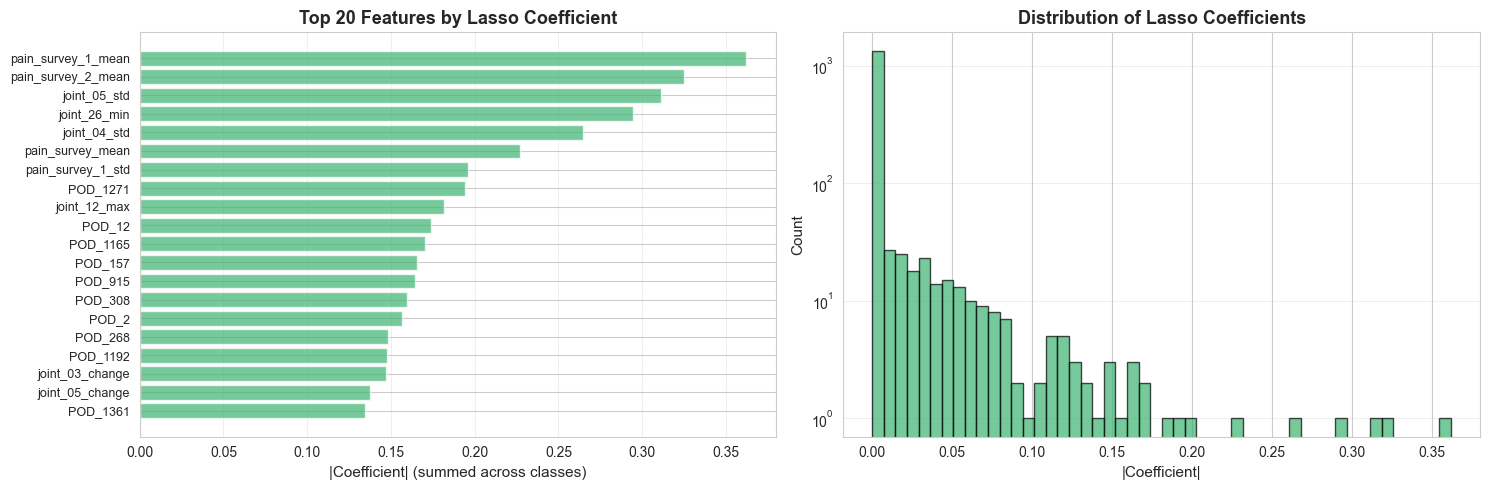

In [11]:
# Visualize Lasso results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Top 20 features
top_20_lasso = lasso_df.head(20)
axes[0].barh(range(len(top_20_lasso)), top_20_lasso['coefficient'].values, alpha=0.7, color='mediumseagreen')
axes[0].set_yticks(range(len(top_20_lasso)))
axes[0].set_yticklabels(top_20_lasso['feature'].values, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('|Coefficient| (summed across classes)', fontsize=11)
axes[0].set_title('Top 20 Features by Lasso Coefficient', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Distribution of coefficients
axes[1].hist(lasso_df['coefficient'].values, bins=50, edgecolor='black', alpha=0.7, color='mediumseagreen')
axes[1].set_xlabel('|Coefficient|', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Distribution of Lasso Coefficients', fontsize=13, fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 8. Method Comparison

Compare features selected by different methods.

In [12]:
# Compare methods
methods = {
    'Variance + Correlation': set(corr_selected_features),
    f'RandomForest (top {top_k_rf})': set(rf_selected_features),
    f'Mutual Info (top {top_k_mi})': set(mi_selected_features),
    f'Lasso ({len(lasso_selected_features)} non-zero)': set(lasso_selected_features)
}

# Print summary
print("Feature Selection Summary:")
print("=" * 60)
for method, features in methods.items():
    print(f"{method:40s}: {len(features):4d} features")

# Find intersection of top methods
rf_set = set(rf_selected_features)
mi_set = set(mi_selected_features)
lasso_set = set(lasso_selected_features)

# Features selected by all three
all_three = rf_set & mi_set & lasso_set
print(f"\nFeatures selected by ALL methods: {len(all_three)}")

# Features selected by at least 2 methods
at_least_two = (rf_set & mi_set) | (rf_set & lasso_set) | (mi_set & lasso_set)
print(f"Features selected by AT LEAST 2 methods: {len(at_least_two)}")

# Recommended: Union of RF and MI (both capture different aspects)
recommended = rf_set | mi_set
print(f"\nRecommended (RF ∪ MI): {len(recommended)} features")

Feature Selection Summary:
Variance + Correlation                  : 1556 features
RandomForest (top 300)                  :  300 features
Mutual Info (top 300)                   :  300 features
Lasso (240 non-zero)                    :  240 features

Features selected by ALL methods: 31
Features selected by AT LEAST 2 methods: 200

Recommended (RF ∪ MI): 456 features


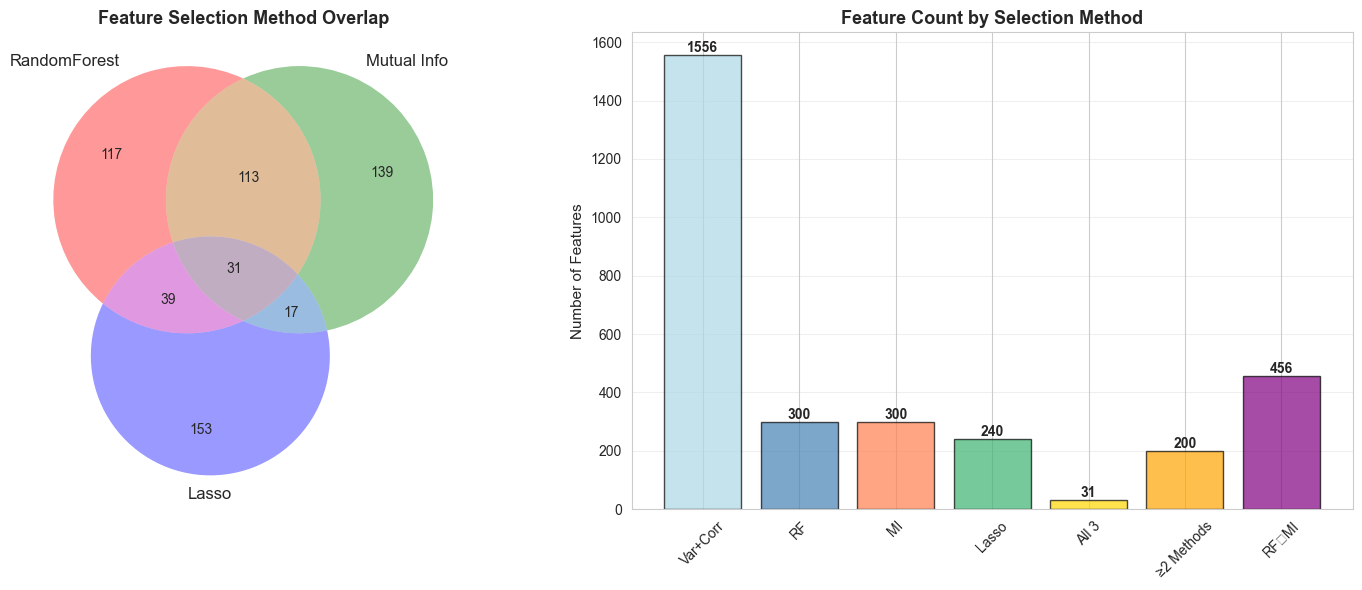

In [13]:
# Visualize overlap using Venn-style bar chart
from matplotlib_venn import venn3

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Venn diagram
venn3([rf_set, mi_set, lasso_set], 
      set_labels=('RandomForest', 'Mutual Info', 'Lasso'),
      ax=axes[0])
axes[0].set_title('Feature Selection Method Overlap', fontsize=13, fontweight='bold')

# Bar chart comparison
method_names = ['Var+Corr', 'RF', 'MI', 'Lasso', 'All 3', '≥2 Methods', 'RF∪MI']
method_counts = [
    len(corr_selected_features),
    len(rf_selected_features),
    len(mi_selected_features),
    len(lasso_selected_features),
    len(all_three),
    len(at_least_two),
    len(recommended)
]
colors = ['lightblue', 'steelblue', 'coral', 'mediumseagreen', 'gold', 'orange', 'purple']

axes[1].bar(method_names, method_counts, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Number of Features', fontsize=11)
axes[1].set_title('Feature Count by Selection Method', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=45)

# Add value labels on bars
for i, (name, count) in enumerate(zip(method_names, method_counts)):
    axes[1].text(i, count + 10, str(count), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Feature Type Analysis

Analyze which types of features are most important.

In [14]:
# Categorize features by type
def categorize_feature(feature_name):
    if 'POD_' in feature_name:
        return 'POD'
    elif 'isPirate' in feature_name:
        return 'isPirate'
    elif '_mean' in feature_name or '_std' in feature_name or '_min' in feature_name or '_max' in feature_name or '_range' in feature_name:
        return 'Statistical'
    elif '_slope' in feature_name or '_first' in feature_name or '_last' in feature_name or '_change' in feature_name:
        return 'Trend'
    elif 'pain_survey' in feature_name or 'joint_activity' in feature_name:
        return 'Domain'
    else:
        return 'Other'

# Categorize RF top features
rf_categories = [categorize_feature(f) for f in rf_selected_features]
rf_category_counts = pd.Series(rf_categories).value_counts()

# Categorize MI top features
mi_categories = [categorize_feature(f) for f in mi_selected_features]
mi_category_counts = pd.Series(mi_categories).value_counts()

print("Feature Type Distribution in Selected Features:")
print("=" * 60)
print("\nRandomForest Top 300:")
print(rf_category_counts)
print("\nMutual Information Top 300:")
print(mi_category_counts)

Feature Type Distribution in Selected Features:

RandomForest Top 300:
POD            238
Statistical     50
Trend           12
Name: count, dtype: int64

Mutual Information Top 300:
POD            236
Statistical     52
Trend           12
Name: count, dtype: int64


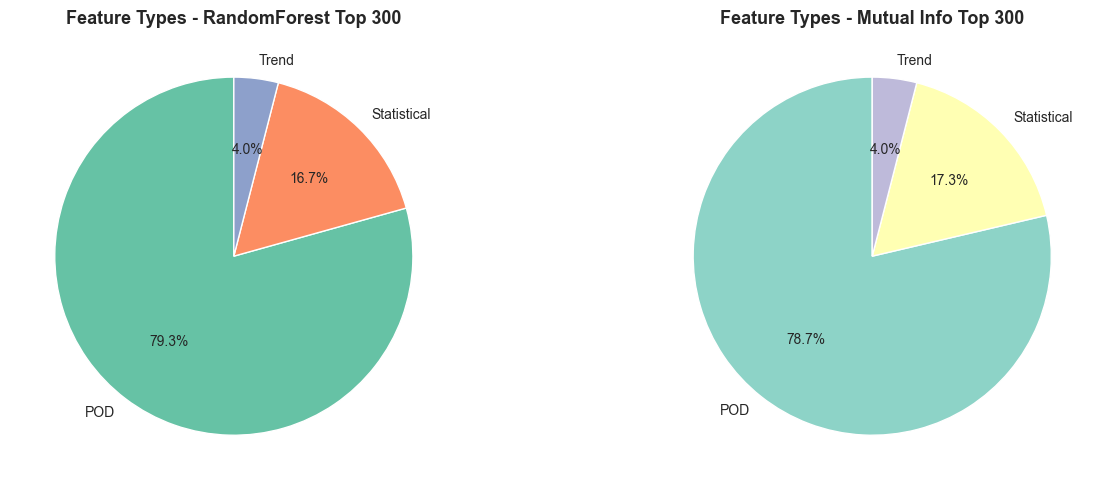

In [15]:
# Visualize feature type distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RandomForest
axes[0].pie(rf_category_counts.values, labels=rf_category_counts.index, autopct='%1.1f%%',
            startangle=90, colors=sns.color_palette('Set2'))
axes[0].set_title('Feature Types - RandomForest Top 300', fontsize=13, fontweight='bold')

# Mutual Information
axes[1].pie(mi_category_counts.values, labels=mi_category_counts.index, autopct='%1.1f%%',
            startangle=90, colors=sns.color_palette('Set3'))
axes[1].set_title('Feature Types - Mutual Info Top 300', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 10. Feature Selection Summary

Summary of different feature selection methods and their results.

In [ ]:
# Summary of feature sets
feature_sets = {
    'RF Top 300': rf_selected_features,
    'MI Top 300': mi_selected_features,
    'Lasso Non-Zero': lasso_selected_features,
    'All 3 Intersection': list(all_three),
    'At Least 2 Methods': list(at_least_two),
    'RF ∪ MI': list(recommended)
}

print("Feature Selection Methods Summary:")
print("=" * 60)
for name, features in feature_sets.items():
    print(f"{name:25s}: {len(features):4d} features")

print("\n" + "="*60)
print("RECOMMENDATION:")
print("="*60)
print(f"✓ 'All 3 Intersection' has {len(all_three)} features")
print(f"  → Most robust: Selected by RF, MI, AND Lasso")
print(f"\n✓ 'At Least 2 Methods' has {len(at_least_two)} features")
print(f"  → Balanced: Selected by at least 2 methods")
print(f"\n✓ 'RF ∪ MI' has {len(recommended)} features")
print(f"  → Comprehensive: Union of tree-based and statistical methods")
print("\nNote: Actual feature selection is done automatically during preprocessing.")
print("This notebook is for analysis and validation only.")

✓ Saved 300 features to ../dataset/PirateProcessed/selected_features_rf_top300.txt
✓ Saved 300 features to ../dataset/PirateProcessed/selected_features_mi_top300.txt
✓ Saved 240 features to ../dataset/PirateProcessed/selected_features_lasso_nonzero.txt
✓ Saved 31 features to ../dataset/PirateProcessed/selected_features_all_three_intersection.txt
✓ Saved 200 features to ../dataset/PirateProcessed/selected_features_at_least_two.txt
✓ Saved 456 features to ../dataset/PirateProcessed/selected_features_rf_union_mi.txt

RECOMMENDATION:
Use 'rf_union_mi' (456 features) or 'at_least_two' (200 features)
Both capture complementary information from tree-based and statistical methods.

For best results, try both in Optuna as a hyperparameter!


## 11. Cross-Validation Trial

Validate the selected features using RandomForest with K-Fold cross-validation to ensure robust performance.

In [25]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer

# Define K-Fold cross-validation
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# F1 scorer (macro average for multi-class)
f1_scorer = make_scorer(f1_score, average='macro')

# Test different feature sets
feature_sets_to_test = {
    'All Features (1748)': X,
    'Var + Correlation': X_corr,
    f'RF Top {top_k_rf}': X_rf,
    f'MI Top {top_k_mi}': X_mi,
    'Lasso Non-Zero': X_lasso,
    'All 3 Methods': X_corr[list(all_three)],
    'At Least 2 Methods': X_corr[list(at_least_two)],
    'RF ∪ MI (Recommended)': X_corr[list(recommended)]
}

print("Running 5-Fold Cross-Validation on Different Feature Sets...")
print("=" * 80)

cv_results = {}

for name, X_test in feature_sets_to_test.items():
    print(f"\nTesting: {name} ({X_test.shape[1]} features)")
    
    # Train RandomForest with cross-validation
    rf_cv = RandomForestClassifier(
        n_estimators=500, 
        max_depth=10, 
        random_state=42, 
        n_jobs=-1,
        class_weight='balanced'
    )
    
    # Perform cross-validation
    cv_scores = cross_val_score(rf_cv, X_test, y, cv=skf, scoring=f1_scorer, n_jobs=-1)
    
    # Store results
    cv_results[name] = {
        'scores': cv_scores,
        'mean': cv_scores.mean(),
        'std': cv_scores.std(),
        'n_features': X_test.shape[1]
    }
    
    print(f"  F1 Scores: {cv_scores}")
    print(f"  Mean F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print("\n" + "=" * 80)
print("CROSS-VALIDATION SUMMARY")
print("=" * 80)

Running 5-Fold Cross-Validation on Different Feature Sets...

Testing: All Features (1748) (1748 features)
  F1 Scores: [0.35819879 0.32517883 0.42189088 0.32517883 0.32197592]
  Mean F1: 0.3505 ± 0.0381

Testing: Var + Correlation (1556 features)
  F1 Scores: [0.35819879 0.32517883 0.42189088 0.32517883 0.32197592]
  Mean F1: 0.3505 ± 0.0381

Testing: Var + Correlation (1556 features)
  F1 Scores: [0.3272863  0.29059829 0.38528139 0.29059829 0.29059829]
  Mean F1: 0.3169 ± 0.0370

Testing: RF Top 300 (300 features)
  F1 Scores: [0.3272863  0.29059829 0.38528139 0.29059829 0.29059829]
  Mean F1: 0.3169 ± 0.0370

Testing: RF Top 300 (300 features)
  F1 Scores: [0.50762453 0.48844836 0.42332655 0.4115942  0.4365441 ]
  Mean F1: 0.4535 ± 0.0377

Testing: MI Top 300 (300 features)
  F1 Scores: [0.50211999 0.49269006 0.51757585 0.47960064 0.46491228]
  Mean F1: 0.4914 ± 0.0181

Testing: Lasso Non-Zero (240 features)
  F1 Scores: [0.35819879 0.29059829 0.35072464 0.29059829 0.29059829]
  Mea

In [26]:
# Create results DataFrame
results_df = pd.DataFrame({
    'Feature Set': list(cv_results.keys()),
    'N Features': [cv_results[k]['n_features'] for k in cv_results.keys()],
    'Mean F1': [cv_results[k]['mean'] for k in cv_results.keys()],
    'Std F1': [cv_results[k]['std'] for k in cv_results.keys()]
}).sort_values('Mean F1', ascending=False)

print(results_df.to_string(index=False))

# Find best performing set
best_set = results_df.iloc[0]['Feature Set']
best_f1 = results_df.iloc[0]['Mean F1']
best_n_features = int(results_df.iloc[0]['N Features'])

print("\n" + "=" * 80)
print(f"🏆 BEST PERFORMING: {best_set}")
print(f"   Features: {best_n_features}")
print(f"   Mean F1: {best_f1:.4f} ± {results_df.iloc[0]['Std F1']:.4f}")
print("=" * 80)

          Feature Set  N Features  Mean F1   Std F1
        All 3 Methods          31 0.562325 0.070248
   At Least 2 Methods         200 0.494076 0.041286
           MI Top 300         300 0.491380 0.018125
           RF Top 300         300 0.453508 0.037696
RF ∪ MI (Recommended)         456 0.450877 0.044328
  All Features (1748)        1748 0.350485 0.038084
    Var + Correlation        1556 0.316873 0.037038
       Lasso Non-Zero         240 0.316144 0.031376

🏆 BEST PERFORMING: All 3 Methods
   Features: 31
   Mean F1: 0.5623 ± 0.0702


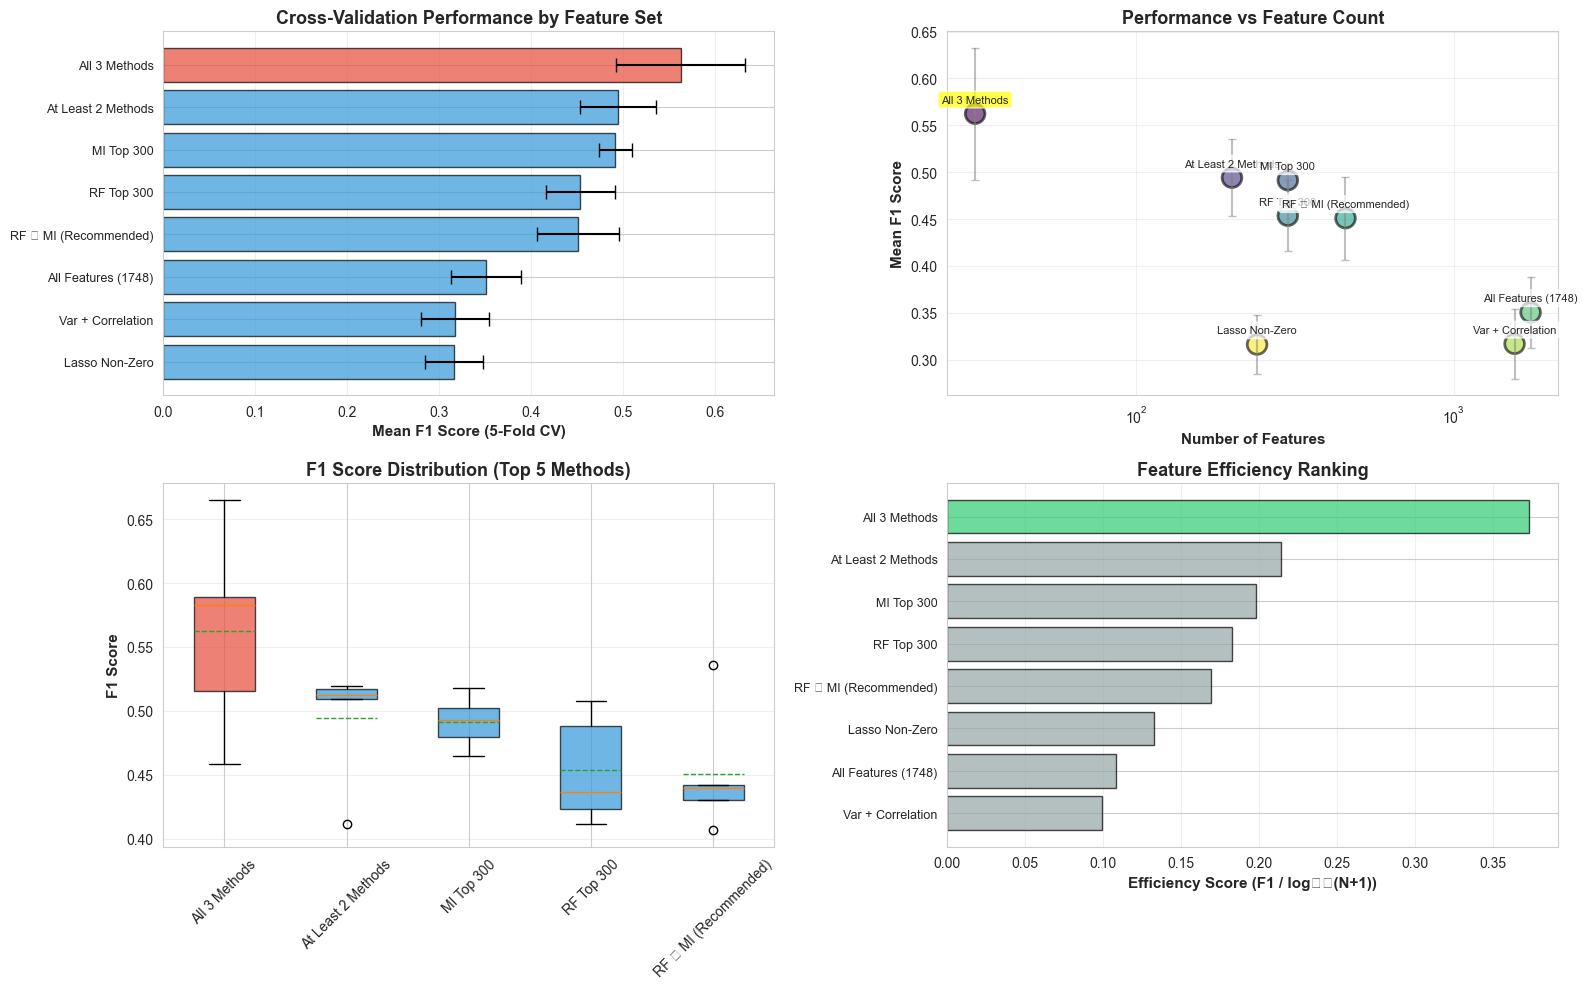


🎯 Most Efficient Feature Set: All 3 Methods
   Efficiency Score: 0.3736
   (Balances performance with feature count)


In [27]:
# Visualize cross-validation results
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Bar chart of mean F1 scores
ax1 = axes[0, 0]
colors_cv = ['#e74c3c' if x == best_set else '#3498db' for x in results_df['Feature Set']]
bars = ax1.barh(range(len(results_df)), results_df['Mean F1'].values, 
                xerr=results_df['Std F1'].values, capsize=5, alpha=0.7, 
                color=colors_cv, edgecolor='black')
ax1.set_yticks(range(len(results_df)))
ax1.set_yticklabels(results_df['Feature Set'].values, fontsize=9)
ax1.set_xlabel('Mean F1 Score (5-Fold CV)', fontsize=11, fontweight='bold')
ax1.set_title('Cross-Validation Performance by Feature Set', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')
ax1.invert_yaxis()

# 2. Performance vs Number of Features
ax2 = axes[0, 1]
ax2.scatter(results_df['N Features'], results_df['Mean F1'], 
           s=200, alpha=0.6, c=range(len(results_df)), cmap='viridis', edgecolors='black', linewidth=2)
ax2.errorbar(results_df['N Features'], results_df['Mean F1'], 
            yerr=results_df['Std F1'], fmt='none', ecolor='gray', alpha=0.5, capsize=3)
# Add labels for each point
for idx, row in results_df.iterrows():
    ax2.annotate(row['Feature Set'], 
                (row['N Features'], row['Mean F1']),
                textcoords="offset points", 
                xytext=(0, 8), 
                ha='center',
                fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow' if row['Feature Set'] == best_set else 'white', alpha=0.7))
ax2.set_xlabel('Number of Features', fontsize=11, fontweight='bold')
ax2.set_ylabel('Mean F1 Score', fontsize=11, fontweight='bold')
ax2.set_title('Performance vs Feature Count', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xscale('log')

# 3. Box plot of CV scores for top 5 methods
ax3 = axes[1, 0]
top_5_methods = results_df.head(5)['Feature Set'].tolist()
cv_scores_top5 = [cv_results[method]['scores'] for method in top_5_methods]
bp = ax3.boxplot(cv_scores_top5, labels=[m[:25] for m in top_5_methods], 
                 patch_artist=True, showmeans=True, meanline=True)
for patch, method in zip(bp['boxes'], top_5_methods):
    patch.set_facecolor('#e74c3c' if method == best_set else '#3498db')
    patch.set_alpha(0.7)
ax3.set_ylabel('F1 Score', fontsize=11, fontweight='bold')
ax3.set_title('F1 Score Distribution (Top 5 Methods)', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='x', rotation=45)

# 4. Efficiency Score: F1 / log(n_features)
ax4 = axes[1, 1]
results_df['Efficiency'] = results_df['Mean F1'] / np.log10(results_df['N Features'] + 1)
efficiency_sorted = results_df.sort_values('Efficiency', ascending=False)
colors_eff = ['#2ecc71' if x == efficiency_sorted.iloc[0]['Feature Set'] else '#95a5a6' for x in efficiency_sorted['Feature Set']]
ax4.barh(range(len(efficiency_sorted)), efficiency_sorted['Efficiency'].values, 
        alpha=0.7, color=colors_eff, edgecolor='black')
ax4.set_yticks(range(len(efficiency_sorted)))
ax4.set_yticklabels(efficiency_sorted['Feature Set'].values, fontsize=9)
ax4.set_xlabel('Efficiency Score (F1 / log₁₀(N+1))', fontsize=11, fontweight='bold')
ax4.set_title('Feature Efficiency Ranking', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')
ax4.invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\n🎯 Most Efficient Feature Set: {efficiency_sorted.iloc[0]['Feature Set']}")
print(f"   Efficiency Score: {efficiency_sorted.iloc[0]['Efficiency']:.4f}")
print(f"   (Balances performance with feature count)")

In [28]:
# Statistical significance test: Compare best vs baseline (all features)
from scipy import stats

best_scores = cv_results[best_set]['scores']
baseline_scores = cv_results['All Features (1748)']['scores']

# Paired t-test
t_stat, p_value = stats.ttest_rel(best_scores, baseline_scores)

print("Statistical Significance Test:")
print("=" * 60)
print(f"Best Feature Set: {best_set}")
print(f"  Mean F1: {best_scores.mean():.4f}")
print(f"\nBaseline (All Features):")
print(f"  Mean F1: {baseline_scores.mean():.4f}")
print(f"\nPaired t-test:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4f}")

if p_value < 0.05:
    if best_scores.mean() > baseline_scores.mean():
        print(f"  ✅ {best_set} is SIGNIFICANTLY BETTER (p < 0.05)")
    else:
        print(f"  ⚠️  {best_set} is significantly worse (p < 0.05)")
else:
    print(f"  ➡️  No significant difference (p >= 0.05)")
    
# Effect size (Cohen's d)
pooled_std = np.sqrt((best_scores.std()**2 + baseline_scores.std()**2) / 2)
cohens_d = (best_scores.mean() - baseline_scores.mean()) / pooled_std
print(f"  Cohen's d (effect size): {cohens_d:.4f}")

if abs(cohens_d) < 0.2:
    print("    → Small effect")
elif abs(cohens_d) < 0.5:
    print("    → Medium effect")
else:
    print("    → Large effect")

print("\n" + "=" * 60)

Statistical Significance Test:
Best Feature Set: All 3 Methods
  Mean F1: 0.5623

Baseline (All Features):
  Mean F1: 0.3505

Paired t-test:
  t-statistic: 5.4379
  p-value: 0.0056
  ✅ All 3 Methods is SIGNIFICANTLY BETTER (p < 0.05)
  Cohen's d (effect size): 3.7492
    → Large effect

